# 06. Noncompliance, Intent-to-Treat, and Treatment-on-Treated

Randomized experiments are cleanest when assignment and treatment receipt are the same thing. We assign a user to treatment, the user receives the treatment; we assign a user to control, the user does not receive it. Real deployments are rarely that tidy.

A customer may be invited to use a new AI assistant but never open it. A salesperson may be assigned a new forecasting workflow but keep using the old spreadsheet. A patient may be offered a reminder program but opt out. A control user may discover an unreleased feature through a shared workspace. A manager may override assignment because the rollout is operationally inconvenient.

This is **noncompliance**: the assigned condition differs from the treatment actually received.

The central idea of this notebook is:

> Random assignment identifies the causal effect of assignment. Estimating the causal effect of actual treatment receipt requires extra assumptions.

That distinction is not semantic. It changes what we can claim, what estimate belongs in the executive readout, and how we should design the next experiment.

## Learning Goals

By the end of this notebook, you should be able to:

- Distinguish assignment $Z$, treatment receipt $D$, and outcome $Y$.
- Estimate and interpret the intent-to-treat effect on outcomes.
- Estimate and interpret the first stage, or effect of assignment on treatment receipt.
- Explain why naive treated-versus-untreated comparisons are usually biased under noncompliance.
- Compute the treatment-on-treated estimate in one-sided noncompliance settings.
- Compute the Wald instrumental-variables estimate in two-sided noncompliance settings.
- State the assumptions behind a local average treatment effect: relevance, independence, exclusion, and monotonicity.
- Explain why LATE is an effect for compliers, not necessarily the full-population ATE.
- Diagnose weak first stages and understand why weak compliance makes estimates unstable.
- Write a professional noncompliance readout for a product or industry experiment.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "assignment": "#d7ecff",
    "receipt": "#ffe0c2",
    "outcome": "#eadcf8",
    "bias": "#ffd6db",
    "assumption": "#fff1c7",
    "analysis": "#e1f3ef",
    "neutral": "#f7f7f7",
}

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Create a Graphviz diagram with consistent lecture styling."""
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.70")
    dot.attr(
        "node",
        shape="box",
        style="rounded,filled",
        color="#2b2b2b",
        fontname="Helvetica",
        fontsize="11",
        margin="0.12,0.08",
    )
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            dot.edge(src, dst)
        elif len(edge) == 3:
            src, dst, label = edge
            dot.edge(src, dst, label=label)
    return dot


def diff_in_means(df, outcome, group):
    treated = df.loc[df[group] == 1, outcome]
    control = df.loc[df[group] == 0, outcome]
    est = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / len(treated) + control.var(ddof=1) / len(control))
    return {
        "estimate": est,
        "se": se,
        "ci_low": est - 1.96 * se,
        "ci_high": est + 1.96 * se,
        "p_value": stats.ttest_ind(treated, control, equal_var=False).pvalue,
    }


def bootstrap_wald(df, y="outcome", d="used_assistant", z="assigned", n_boot=800, seed=123):
    local_rng = np.random.default_rng(seed)
    n = len(df)
    estimates = []
    for _ in range(n_boot):
        sample = df.iloc[local_rng.integers(0, n, size=n)]
        itt_y = sample.loc[sample[z] == 1, y].mean() - sample.loc[sample[z] == 0, y].mean()
        itt_d = sample.loc[sample[z] == 1, d].mean() - sample.loc[sample[z] == 0, d].mean()
        if abs(itt_d) > 1e-8:
            estimates.append(itt_y / itt_d)
    estimates = np.array(estimates)
    return {
        "estimate": np.mean(estimates),
        "se": np.std(estimates, ddof=1),
        "ci_low": np.quantile(estimates, 0.025),
        "ci_high": np.quantile(estimates, 0.975),
    }


def plot_ci_table(table, title, xlabel, reference=None, figsize=(9, 4.2)):
    ordered = table.sort_values("estimate")
    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(ordered))
    ax.errorbar(
        ordered["estimate"],
        y,
        xerr=[ordered["estimate"] - ordered["ci_low"], ordered["ci_high"] - ordered["estimate"]],
        fmt="o",
        color="#2f6f9f",
        ecolor="#2f6f9f",
        elinewidth=2,
        capsize=4,
    )
    if reference is not None:
        ax.axvline(reference, color="#b23b3b", linestyle="--", linewidth=2, label="Reference")
        ax.legend(loc="lower right")
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(ordered["method"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## 1. Assignment, Receipt, and Outcome

We need three variables.

| Symbol | Meaning | Product example |
|---|---|---|
| $Z$ | Random assignment or encouragement | Assigned to receive an AI assistant invite |
| $D$ | Actual treatment receipt or usage | Actually used the AI assistant |
| $Y$ | Outcome | Tasks completed per week, revenue, retention, satisfaction |

In a perfect experiment, $D = Z$. With noncompliance, $D$ can differ from $Z$.

The most important rule is:

> $Z$ is randomized. $D$ is usually a post-assignment behavior.

That means comparisons by $Z$ inherit the protection of randomization. Comparisons by $D$ usually do not.

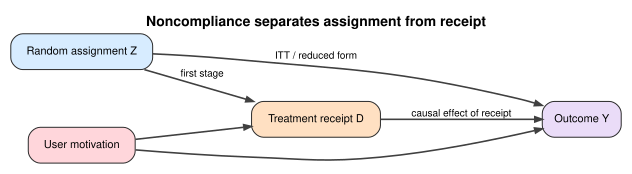

In [3]:
noncompliance_edges = [
    ("Random assignment Z", "Treatment receipt D", "first stage"),
    ("Treatment receipt D", "Outcome Y", "causal effect of receipt"),
    ("User motivation", "Treatment receipt D"),
    ("User motivation", "Outcome Y"),
    ("Random assignment Z", "Outcome Y", "ITT / reduced form"),
]
noncompliance_colors = {
    "Random assignment Z": COLORS["assignment"],
    "Treatment receipt D": COLORS["receipt"],
    "Outcome Y": COLORS["outcome"],
    "User motivation": COLORS["bias"],
}

display(make_dag(noncompliance_edges, "Noncompliance separates assignment from receipt", noncompliance_colors))

### Interpretation

The diagram shows why treated-versus-untreated comparisons can be biased. Treatment receipt is affected by assignment, but it may also be affected by motivation, capacity, manager support, technical skill, or need. Those same factors may affect the outcome.

The random assignment $Z$ is the clean source of variation. We can always estimate the effect of assignment. Estimating the effect of receipt requires using $Z$ as an instrument for $D$ and accepting additional assumptions.

## 2. Three Estimands Teams Often Confuse

Suppose an experiment randomly invites users to an AI assistant. Some invited users do not use it. The team may ask three different questions.

| Estimand | Formula | Question |
|---|---|---|
| Intent-to-treat on outcome | $ITT_Y = E[Y \mid Z=1] - E[Y \mid Z=0]$ | What is the effect of assigning or inviting users? |
| First stage | $ITT_D = E[D \mid Z=1] - E[D \mid Z=0]$ | How much did assignment change actual usage? |
| Treatment-on-treated / LATE | $\dfrac{ITT_Y}{ITT_D}$ | What is the effect for users whose usage was changed by assignment? |

Athey and Imbens (2017) describe two broad ways to handle noncompliance in randomized experiments: analyze assignment through an intention-to-treat analysis, or use instrumental-variables logic to estimate the local average treatment effect for compliers. Angrist, Imbens, and Rubin (1996) formalized the assumptions under which the instrumental-variables estimand has this complier-average causal interpretation.

## 3. Simulating One-Sided Noncompliance

First consider **one-sided noncompliance**. Users assigned to control cannot access the assistant. Users assigned to treatment can access it, but only some choose to use it.

This setting is common when the treatment is a gated offer, invite, coupon, enablement program, or training opportunity.

We will simulate:

- Random assignment $Z$.
- A latent engagement trait that affects usage and outcomes.
- Treatment usage $D$ only among assigned users.
- A true effect of usage on the outcome.

In [4]:
def simulate_one_sided_noncompliance(n=8000, assignment_rate=0.5, true_tot=4.0, seed=20260428):
    local_rng = np.random.default_rng(seed)
    motivation = local_rng.normal(0, 1, n)
    baseline_skill = local_rng.normal(0, 1, n)
    z = local_rng.binomial(1, assignment_rate, n)

    # Only assigned users can use the assistant. More motivated users are more likely to take it up.
    p_use_if_assigned = 1 / (1 + np.exp(-(-0.25 + 1.0 * motivation + 0.35 * baseline_skill)))
    d = np.where(z == 1, local_rng.binomial(1, p_use_if_assigned), 0)

    pre_outcome = 50 + 4.0 * motivation + 2.0 * baseline_skill + local_rng.normal(0, 5, n)
    y0 = 52 + 4.0 * motivation + 2.0 * baseline_skill + 0.45 * pre_outcome + local_rng.normal(0, 6, n)
    y = y0 + true_tot * d

    return pd.DataFrame({
        "assigned": z,
        "used_assistant": d,
        "outcome": y,
        "pre_outcome": pre_outcome,
        "motivation": motivation,
        "baseline_skill": baseline_skill,
        "true_usage_effect": true_tot,
    })


df_one = simulate_one_sided_noncompliance()
summary_one = pd.DataFrame({
    "quantity": [
        "Rows",
        "Assignment rate",
        "Usage rate if assigned",
        "Usage rate if control",
        "Overall usage rate",
    ],
    "value": [
        len(df_one),
        df_one["assigned"].mean(),
        df_one.query("assigned == 1")["used_assistant"].mean(),
        df_one.query("assigned == 0")["used_assistant"].mean(),
        df_one["used_assistant"].mean(),
    ],
})
summary_one

,quantity,value
0,Rows,8000.000000
1,Assignment rate,0.492875
2,Usage rate if assigned,0.445853
3,Usage rate if control,0.000000
4,Overall usage rate,0.219750


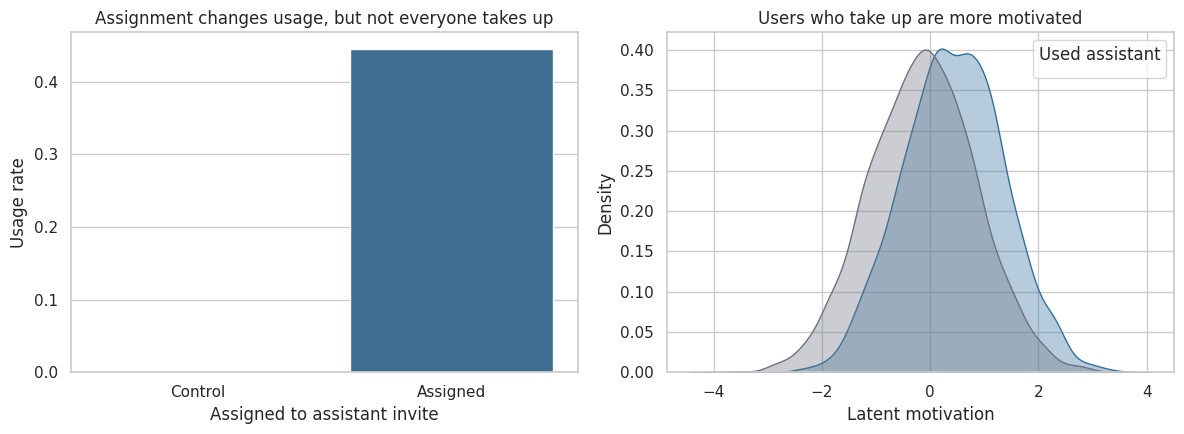

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

usage_by_assignment = df_one.groupby("assigned", as_index=False)["used_assistant"].mean()
sns.barplot(data=usage_by_assignment, x="assigned", y="used_assistant", color="#2f6f9f", ax=axes[0])
axes[0].set_title("Assignment changes usage, but not everyone takes up")
axes[0].set_xlabel("Assigned to assistant invite")
axes[0].set_ylabel("Usage rate")
axes[0].set_xticklabels(["Control", "Assigned"])

sns.kdeplot(
    data=df_one,
    x="motivation",
    hue="used_assistant",
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette={0: "#6b7280", 1: "#2f6f9f"},
    ax=axes[1],
)
axes[1].set_title("Users who take up are more motivated")
axes[1].set_xlabel("Latent motivation")
handles, _ = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=["Did not use", "Used"], title="Used assistant")
plt.tight_layout()
plt.show()

### Interpretation

The usage chart shows noncompliance: assignment increases usage, but assignment is not the same as usage. The motivation plot shows why naive comparisons by usage are risky. Users who actually use the assistant are different from users who do not.

This is the core failure mode. If a team compares users who used the assistant to users who did not, the result blends the effect of the assistant with differences in motivation and skill.

## 4. ITT, First Stage, and the Bloom / Wald Adjustment

The **intent-to-treat** effect estimates the effect of assignment:

$$
ITT_Y = E[Y \mid Z=1] - E[Y \mid Z=0].
$$

The **first stage** estimates the effect of assignment on actual usage:

$$
ITT_D = E[D \mid Z=1] - E[D \mid Z=0].
$$

In a one-sided noncompliance design, a common treatment-on-treated adjustment is:

$$
TOT = \frac{ITT_Y}{ITT_D}.
$$

Bloom (1984) discussed this no-shows adjustment in experimental evaluation designs. In the broader instrumental-variables language, the same ratio is a Wald estimand. Under the LATE assumptions, it estimates the average causal effect for compliers: users whose usage is changed by assignment (Imbens & Angrist, 1994; Angrist et al., 1996).

In [6]:
itt_y_one = diff_in_means(df_one, "outcome", "assigned")
itt_d_one = diff_in_means(df_one, "used_assistant", "assigned")
wald_one = bootstrap_wald(df_one, n_boot=800, seed=42)
naive_use = diff_in_means(df_one, "outcome", "used_assistant")

one_readout = pd.DataFrame([
    {"method": "ITT: assigned vs control", **itt_y_one},
    {"method": "Naive: used vs not used", **naive_use},
    {"method": "TOT / Wald: ITT divided by first stage", **wald_one},
])

first_stage_table = pd.DataFrame({
    "quantity": ["ITT on outcome", "First stage", "Wald / TOT", "True usage effect"],
    "value": [itt_y_one["estimate"], itt_d_one["estimate"], itt_y_one["estimate"] / itt_d_one["estimate"], 4.0],
})
first_stage_table.round(3)

,quantity,value
0,ITT on outcome,1.937
1,First stage,0.446
2,Wald / TOT,4.345
3,True usage effect,4.000


In [7]:
one_readout[["method", "estimate", "se", "ci_low", "ci_high"]].round(3)

,method,estimate,se,ci_low,ci_high
0,ITT: assigned vs control,1.937,0.211,1.525,2.350
1,Naive: used vs not used,7.678,0.235,7.217,8.140
2,TOT / Wald: ITT divided by first stage,4.351,0.457,3.480,5.238


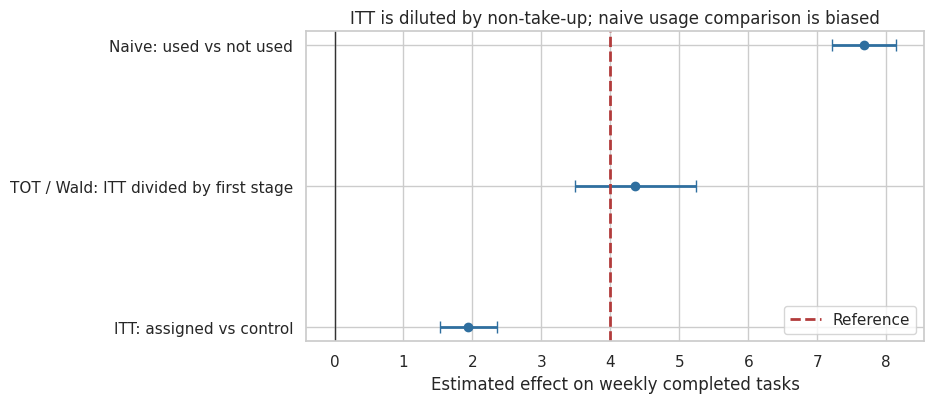

In [8]:
plot_ci_table(
    one_readout,
    title="ITT is diluted by non-take-up; naive usage comparison is biased",
    xlabel="Estimated effect on weekly completed tasks",
    reference=4.0,
    figsize=(9.5, 4.2),
)

### Interpretation

The ITT is smaller than the true usage effect because assignment only moves some users into usage. If assignment increases usage by roughly 40 percentage points, then a usage effect of about 4 units produces an assignment effect of about $4 \times 0.40 = 1.6$ units.

The naive used-versus-not-used comparison is usually too large in this simulation because usage is selective: motivated users both use the assistant and have higher outcomes. The Wald/TOT estimate uses only the randomized change in usage induced by assignment. That is why it lands near the true usage effect.

## 5. Compliance Types and Principal Strata

It helps to imagine each unit's potential treatment receipt under assignment and control:

$$
D_i(1), \qquad D_i(0).
$$

These define four compliance types.

| Type | $D_i(1)$ | $D_i(0)$ | Meaning |
|---|---:|---:|---|
| Complier | 1 | 0 | Uses treatment if assigned, does not use it if not assigned |
| Never-taker | 0 | 0 | Does not use treatment regardless of assignment |
| Always-taker | 1 | 1 | Uses treatment regardless of assignment |
| Defier | 0 | 1 | Does the opposite of assignment |

The LATE framework focuses on compliers. Imbens and Angrist (1994) and Angrist, Imbens, and Rubin (1996) showed that, under specific assumptions, the IV/Wald estimand identifies the treatment effect for this complier group.

The important practical warning is:

> We do not directly observe a person's compliance type. We observe one realized assignment and one realized receipt.

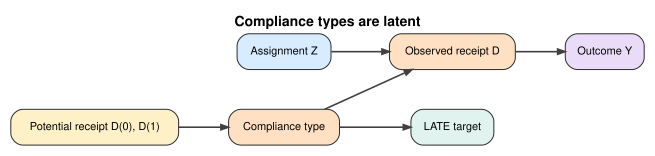

In [9]:
principal_edges = [
    ("Potential receipt D(0), D(1)", "Compliance type"),
    ("Compliance type", "Observed receipt D"),
    ("Assignment Z", "Observed receipt D"),
    ("Observed receipt D", "Outcome Y"),
    ("Compliance type", "LATE target"),
]
principal_colors = {
    "Potential receipt D(0), D(1)": COLORS["assumption"],
    "Compliance type": COLORS["receipt"],
    "Observed receipt D": COLORS["receipt"],
    "Assignment Z": COLORS["assignment"],
    "Outcome Y": COLORS["outcome"],
    "LATE target": COLORS["analysis"],
}

display(make_dag(principal_edges, "Compliance types are latent", principal_colors))

### Interpretation

If someone is assigned to treatment and uses it, that person could be a complier or an always-taker. If someone is assigned to control and does not use it, that person could be a complier or a never-taker. Compliance type is partially hidden, which is why the assumptions matter.

## 6. Two-Sided Noncompliance

Now consider **two-sided noncompliance**. Some assigned users do not use the assistant, and some control users gain access through another path.

This happens in industry when:

- Teams share access across workspaces.
- Managers manually override rollout status.
- A feature is available through a legacy route.
- A marketplace treatment leaks across agents or regions.
- Users in control receive a similar treatment from another campaign.

The Wald estimand becomes:

$$
\frac{E[Y \mid Z=1] - E[Y \mid Z=0]}{E[D \mid Z=1] - E[D \mid Z=0]}.
$$

The denominator is no longer just the treatment-group take-up rate; it is the difference in treatment receipt between assigned and control groups.

In [10]:
def simulate_two_sided_noncompliance(n=9000, true_late=5.0, seed=20260429):
    local_rng = np.random.default_rng(seed)
    z = local_rng.binomial(1, 0.5, n)
    engagement = local_rng.normal(0, 1, n)
    account_size = local_rng.gamma(shape=2.0, scale=1.0, size=n)

    # Latent compliance class probabilities.
    p_always = 1 / (1 + np.exp(1.9 - 0.7 * engagement))
    p_never = 1 / (1 + np.exp(0.9 + 0.9 * engagement))
    u = local_rng.uniform(size=n)
    compliance_type = np.where(
        u < p_always,
        "always-taker",
        np.where(u < p_always + p_never, "never-taker", "complier"),
    )

    d0 = np.where(compliance_type == "always-taker", 1, 0)
    d1 = np.where(compliance_type == "never-taker", 0, 1)
    d = np.where(z == 1, d1, d0)

    # Compliers have the largest effect; always-takers and never-takers would have different effects.
    tau = np.select(
        [compliance_type == "complier", compliance_type == "always-taker", compliance_type == "never-taker"],
        [true_late, 3.0, 1.5],
    )
    y0 = 60 + 5.0 * engagement + 1.8 * account_size + local_rng.normal(0, 7, n)
    y = y0 + tau * d

    return pd.DataFrame({
        "assigned": z,
        "used_assistant": d,
        "outcome": y,
        "engagement": engagement,
        "account_size": account_size,
        "compliance_type": compliance_type,
        "true_effect": tau,
    })


df_two = simulate_two_sided_noncompliance()
compliance_summary = (
    df_two.groupby("compliance_type", as_index=False)
    .agg(count=("outcome", "size"), mean_true_effect=("true_effect", "mean"))
)
compliance_summary["share"] = compliance_summary["count"] / len(df_two)
compliance_summary.round(3)

,compliance_type,count,mean_true_effect,share
0,always-taker,1317,3.0,0.146
1,complier,4822,5.0,0.536
2,never-taker,2861,1.5,0.318


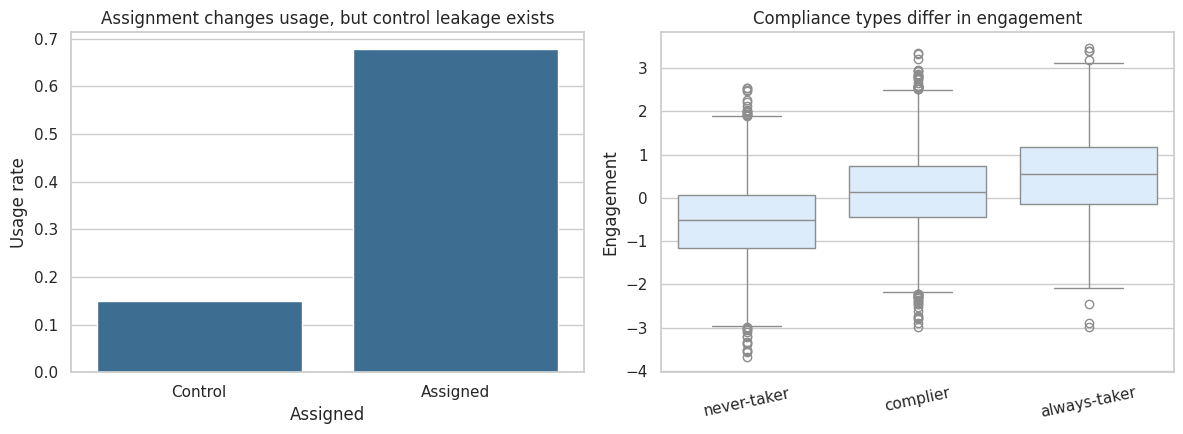

In [11]:
receipt_by_assignment = df_two.groupby("assigned", as_index=False)["used_assistant"].mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=receipt_by_assignment, x="assigned", y="used_assistant", color="#2f6f9f", ax=axes[0])
axes[0].set_title("Assignment changes usage, but control leakage exists")
axes[0].set_xlabel("Assigned")
axes[0].set_ylabel("Usage rate")
axes[0].set_xticklabels(["Control", "Assigned"])

sns.boxplot(data=df_two, x="compliance_type", y="engagement", color="#d7ecff", ax=axes[1])
axes[1].set_title("Compliance types differ in engagement")
axes[1].set_xlabel("")
axes[1].set_ylabel("Engagement")
axes[1].tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()

In [12]:
itt_y_two = diff_in_means(df_two, "outcome", "assigned")
itt_d_two = diff_in_means(df_two, "used_assistant", "assigned")
wald_two = bootstrap_wald(df_two, n_boot=800, seed=43)
naive_two = diff_in_means(df_two, "outcome", "used_assistant")
true_ate_two = df_two["true_effect"].mean()
true_late_two = df_two.query("compliance_type == 'complier'")["true_effect"].mean()

comparison_two = pd.DataFrame([
    {"method": "ITT: assigned vs control", **itt_y_two},
    {"method": "Naive: used vs not used", **naive_two},
    {"method": "Wald IV / LATE", **wald_two},
])

pd.DataFrame({
    "quantity": ["ITT on outcome", "First stage", "Wald IV", "True full-population ATE", "True complier LATE"],
    "value": [
        itt_y_two["estimate"],
        itt_d_two["estimate"],
        itt_y_two["estimate"] / itt_d_two["estimate"],
        true_ate_two,
        true_late_two,
    ],
}).round(3)

,quantity,value
0,ITT on outcome,2.510
1,First stage,0.529
2,Wald IV,4.746
3,True full-population ATE,3.595
4,True complier LATE,5.000


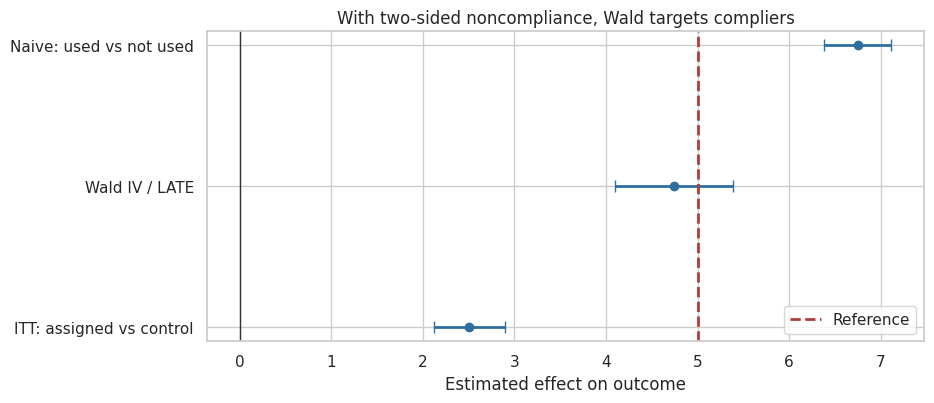

In [13]:
plot_ci_table(
    comparison_two,
    title="With two-sided noncompliance, Wald targets compliers",
    xlabel="Estimated effect on outcome",
    reference=true_late_two,
    figsize=(9.5, 4.2),
)

### Interpretation

The Wald estimate is close to the true complier effect, not necessarily the full-population average effect. This is the defining feature of LATE. If treatment effects differ by compliance type, the IV estimate answers a local question: the effect for units whose usage was changed by assignment.

That local question can be exactly what the business needs. For example, if an invite campaign only changes behavior for persuadable accounts, the complier effect describes the return among accounts the campaign can actually move. But it should not be mislabeled as the effect for all users.

## 7. The Four Core LATE Assumptions

The Wald/IV estimate is not magic. It needs assumptions.

| Assumption | Meaning in the AI assistant example | How it can fail |
|---|---|---|
| Relevance | Assignment changes assistant usage | Invite is ignored; access is already universal |
| Independence | Assignment is randomized | Managers override assignment based on expected benefit |
| Exclusion | Assignment affects outcome only through usage | Invite email itself motivates users or changes expectations |
| Monotonicity | No defiers: assignment does not make anyone less likely to use | Assigned users avoid the assistant because the invite annoys them |

These assumptions are the reason IV/LATE analysis is more demanding than ITT analysis. ITT mainly needs valid random assignment and well-measured outcomes. LATE additionally needs a credible story about how assignment changes receipt.

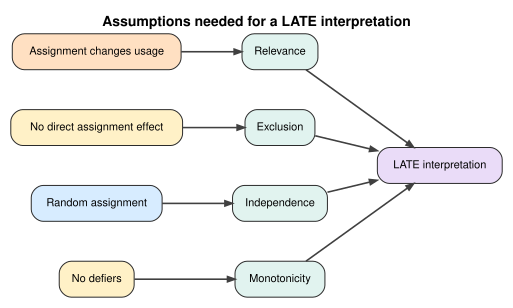

In [14]:
assumption_edges = [
    ("Random assignment", "Independence"),
    ("Assignment changes usage", "Relevance"),
    ("No direct assignment effect", "Exclusion"),
    ("No defiers", "Monotonicity"),
    ("Independence", "LATE interpretation"),
    ("Relevance", "LATE interpretation"),
    ("Exclusion", "LATE interpretation"),
    ("Monotonicity", "LATE interpretation"),
]
assumption_colors = {
    "Random assignment": COLORS["assignment"],
    "Assignment changes usage": COLORS["receipt"],
    "No direct assignment effect": COLORS["assumption"],
    "No defiers": COLORS["assumption"],
    "Independence": COLORS["analysis"],
    "Relevance": COLORS["analysis"],
    "Exclusion": COLORS["analysis"],
    "Monotonicity": COLORS["analysis"],
    "LATE interpretation": COLORS["outcome"],
}

display(make_dag(assumption_edges, "Assumptions needed for a LATE interpretation", assumption_colors))

### Interpretation

The assumptions are often more important than the formula. Two experiments can have the same Wald ratio, but one may have a credible LATE interpretation and the other may not. In product settings, exclusion is often the hardest assumption because assignment can change notifications, expectations, manager attention, support, or visibility, even if the user never uses the treatment.

## 8. Weak First Stages Make Estimates Unstable

The Wald estimate divides by the first stage. If assignment barely changes treatment receipt, the denominator is small.

$$
\widehat{LATE} = \frac{\widehat{ITT}_Y}{\widehat{ITT}_D}.
$$

When $\widehat{ITT}_D$ is small, small noise in the numerator can create very large ratio estimates. This is why an experiment with low take-up can be excellent for ITT but poor for estimating treatment-on-treated effects.

In [15]:
def simulate_first_stage_strength(n=5000, first_stage_target=0.5, true_effect=4.0, seed=0):
    local_rng = np.random.default_rng(seed)
    z = local_rng.binomial(1, 0.5, n)
    motivation = local_rng.normal(0, 1, n)
    base_p = 0.08
    p_control = base_p + 0.04 * (motivation > 0)
    p_treat = np.clip(p_control + first_stage_target, 0, 0.95)
    d = local_rng.binomial(1, np.where(z == 1, p_treat, p_control))
    y0 = 40 + 4.0 * motivation + local_rng.normal(0, 8, n)
    y = y0 + true_effect * d
    df = pd.DataFrame({"assigned": z, "used_assistant": d, "outcome": y})
    itt_y = diff_in_means(df, "outcome", "assigned")["estimate"]
    itt_d = diff_in_means(df, "used_assistant", "assigned")["estimate"]
    return itt_y, itt_d, itt_y / itt_d

strength_rows = []
for target in [0.05, 0.10, 0.20, 0.40, 0.65]:
    for sim in range(350):
        itt_y, itt_d, wald = simulate_first_stage_strength(
            first_stage_target=target,
            seed=100_000 + int(target * 1000) * 1000 + sim,
        )
        strength_rows.append({
            "target_first_stage": target,
            "estimated_first_stage": itt_d,
            "wald_estimate": wald,
        })
strength_df = pd.DataFrame(strength_rows)

strength_summary = (
    strength_df.groupby("target_first_stage")
    .agg(
        mean_first_stage=("estimated_first_stage", "mean"),
        mean_wald=("wald_estimate", "mean"),
        sd_wald=("wald_estimate", "std"),
        p05=("wald_estimate", lambda x: np.quantile(x, 0.05)),
        p95=("wald_estimate", lambda x: np.quantile(x, 0.95)),
    )
    .reset_index()
)
strength_summary.round(3)

,target_first_stage,mean_first_stage,mean_wald,sd_wald,p05,p95
0,0.05,0.050,3.350,5.357,-4.701,11.627
1,0.10,0.100,3.941,2.521,-0.202,7.890
2,0.20,0.201,4.020,1.267,1.950,6.063
3,0.40,0.400,4.025,0.599,3.086,4.960
4,0.65,0.650,4.021,0.385,3.413,4.665


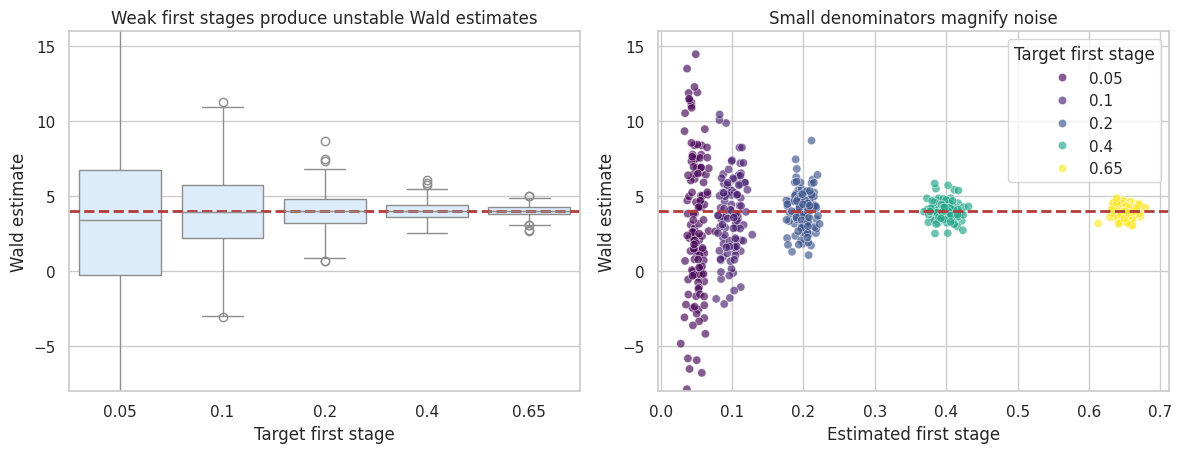

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.7))

sns.boxplot(
    data=strength_df,
    x="target_first_stage",
    y="wald_estimate",
    color="#d7ecff",
    ax=axes[0],
)
axes[0].axhline(4.0, color="#b23b3b", linestyle="--", linewidth=2)
axes[0].set_title("Weak first stages produce unstable Wald estimates")
axes[0].set_xlabel("Target first stage")
axes[0].set_ylabel("Wald estimate")
axes[0].set_ylim(-8, 16)

sns.scatterplot(
    data=strength_df.sample(600, random_state=3),
    x="estimated_first_stage",
    y="wald_estimate",
    hue="target_first_stage",
    palette="viridis",
    alpha=0.65,
    ax=axes[1],
)
axes[1].axhline(4.0, color="#b23b3b", linestyle="--", linewidth=2)
axes[1].set_title("Small denominators magnify noise")
axes[1].set_xlabel("Estimated first stage")
axes[1].set_ylabel("Wald estimate")
axes[1].set_ylim(-8, 16)
axes[1].legend(title="Target first stage", loc="best")
plt.tight_layout()
plt.show()

### Interpretation

When the first stage is strong, the Wald estimates concentrate around the true effect. When the first stage is weak, the estimates become noisy and sometimes extreme. This does not mean the ITT is useless. It means the experiment may be better suited for answering the policy question, "What happens if we send this invite?" than the treatment-receipt question, "What is the effect of using the assistant?"

Bansak (2020) emphasizes that power analysis for LATE has additional complications because noncompliance changes the estimand and the distribution of estimates.

## 9. Why Covariate Adjustment Helps ITT but Does Not Fix Bad Compliance

Pre-treatment covariates can improve precision for ITT and IV analyses. They cannot make a weak or invalid instrument credible.

A useful workflow is:

1. Estimate the ITT with and without pre-treatment covariates.
2. Estimate the first stage with and without pre-treatment covariates.
3. Estimate the Wald ratio or 2SLS-style model if the assumptions are credible.
4. Report the compliance rate and first-stage strength next to any TOT/LATE estimate.

Here is a regression-adjusted view for the one-sided example.

In [17]:
# ITT regression with a pre-treatment covariate.
itt_unadjusted_model = smf.ols("outcome ~ assigned", data=df_one).fit(cov_type="HC1")
itt_adjusted_model = smf.ols("outcome ~ assigned + pre_outcome", data=df_one).fit(cov_type="HC1")
first_stage_adjusted = smf.ols("used_assistant ~ assigned + pre_outcome", data=df_one).fit(cov_type="HC1")

# A simple two-stage least squares by hand for illustration.
first_stage = smf.ols("used_assistant ~ assigned + pre_outcome", data=df_one).fit()
df_one_2sls = df_one.copy()
df_one_2sls["predicted_usage"] = first_stage.fittedvalues
second_stage = smf.ols("outcome ~ predicted_usage + pre_outcome", data=df_one_2sls).fit(cov_type="HC1")

regression_readout = pd.DataFrame({
    "quantity": [
        "Unadjusted ITT on assignment",
        "Adjusted ITT on assignment",
        "Adjusted first stage",
        "Manual 2SLS coefficient on predicted usage",
    ],
    "estimate": [
        itt_unadjusted_model.params["assigned"],
        itt_adjusted_model.params["assigned"],
        first_stage_adjusted.params["assigned"],
        second_stage.params["predicted_usage"],
    ],
    "se": [
        itt_unadjusted_model.bse["assigned"],
        itt_adjusted_model.bse["assigned"],
        first_stage_adjusted.bse["assigned"],
        second_stage.bse["predicted_usage"],
    ],
})
regression_readout.round(3)

,quantity,estimate,se
0,Unadjusted ITT on assignment,1.937,0.211
1,Adjusted ITT on assignment,1.819,0.158
2,Adjusted first stage,0.445,0.008
3,Manual 2SLS coefficient on predicted usage,4.091,0.354


### Interpretation

The adjusted ITT is usually more precise because the pre-period outcome explains some outcome variation. The adjusted first stage tells us whether assignment still strongly changes usage after accounting for baseline outcome differences.

The manual two-stage example is pedagogical. In production analysis, use a well-tested IV implementation with appropriate standard errors. The conceptual point is the same: the first stage isolates assignment-induced variation in usage, and the second stage relates that induced usage to the outcome.

## 10. What Should Go in the Business Readout?

A professional noncompliance readout should not hide take-up. The compliance behavior is part of the product result.

| Readout item | Why it matters |
|---|---|
| Assignment count | Confirms experiment scale |
| Usage or take-up by assignment group | Shows noncompliance directly |
| ITT on the primary outcome | Clean effect of the policy, invite, or rollout |
| First stage | Shows how much assignment changed actual treatment receipt |
| TOT/LATE estimate | Effect among users moved into treatment by assignment, if assumptions are credible |
| Assumptions and threats | Prevents overclaiming |
| Guardrails | Checks whether the rollout harmed something important |
| Recommendation | Should align with whether the decision is about assignment policy or treatment receipt |

The most common executive-summary mistake is to show only the treatment-on-treated estimate because it is larger. The ITT is often the most decision-relevant number: if the business is deciding whether to send the invite or roll out the enablement program, the assignment effect is exactly the policy effect.

In [18]:
business_card = pd.DataFrame({
    "field": [
        "Decision",
        "Randomized assignment",
        "Treatment receipt",
        "Primary ITT estimate",
        "First stage",
        "TOT / LATE estimate",
        "Interpretation",
        "Primary risk",
        "Recommended next action",
    ],
    "example": [
        "Should we invite all eligible teams to the AI assistant?",
        "Invite versus no invite",
        "Opened and used assistant at least twice in week 1",
        f"{itt_y_one['estimate']:.2f} additional completed tasks/week from assignment",
        f"Assignment increased usage by {itt_d_one['estimate']:.1%}",
        f"{(itt_y_one['estimate'] / itt_d_one['estimate']):.2f} tasks/week among assignment-induced users",
        "ITT is the rollout policy effect; TOT describes users whose usage was moved by the invite",
        "Usage is selective, so used-versus-unused comparisons overstate impact",
        "Improve onboarding to raise take-up, then rerun or extend the experiment",
    ],
})
business_card

,field,example
0,Decision,Should we invite all eligible teams to the AI ...
1,Randomized assignment,Invite versus no invite
2,Treatment receipt,Opened and used assistant at least twice in we...
3,Primary ITT estimate,1.94 additional completed tasks/week from assi...
4,First stage,Assignment increased usage by 44.6%
5,TOT / LATE estimate,4.34 tasks/week among assignment-induced users
6,Interpretation,ITT is the rollout policy effect; TOT describe...
7,Primary risk,"Usage is selective, so used-versus-unused comp..."
8,Recommended next action,"Improve onboarding to raise take-up, then reru..."


## 11. Practical Diagnostics for Noncompliance

Before trusting a treatment-on-treated or LATE claim, ask these questions.

| Diagnostic | Healthy sign | Concern |
|---|---|---|
| Assignment integrity | Assignment counts and pre-treatment balance look right | Overrides or sample exclusions after assignment |
| First stage | Assignment materially changes receipt | Small usage difference between assigned and control |
| Exclusion | Assignment only changes outcome through treatment receipt | Notifications, support, or expectations directly affect outcome |
| Monotonicity | Assignment cannot plausibly reduce treatment receipt | Assigned users avoid treatment because assignment changes friction |
| Leakage | Control receipt is low or well understood | Control users access treatment through another route |
| Measurement | Treatment receipt is logged reliably | Usage logs miss important treatment exposure |
| Estimand clarity | ITT and LATE are labeled separately | TOT presented as if it were full-population ATE |

In industry, the engineering and product details are part of the causal design. How access is granted, how usage is logged, whether users can share access, and what assignment changes besides usage all affect the credibility of the analysis.

## 12. Key Takeaways

- Noncompliance means assignment $Z$ and receipt $D$ differ.
- The intent-to-treat effect estimates the causal effect of assignment and is often the cleanest decision metric.
- The first stage measures how much assignment changed treatment receipt.
- Naive treated-versus-untreated comparisons are usually biased because receipt is post-assignment behavior.
- In one-sided noncompliance, a common treatment-on-treated estimate divides the ITT by the treatment-group take-up rate.
- In two-sided noncompliance, the Wald estimate divides the outcome ITT by the receipt ITT.
- Under relevance, independence, exclusion, and monotonicity, the Wald/IV estimand is a local average treatment effect for compliers.
- LATE is not automatically the full-population ATE. It is the effect for units whose treatment receipt was changed by assignment.
- Weak first stages make treatment-on-treated estimates noisy and fragile.
- A trustworthy readout reports assignment effects, compliance rates, first-stage strength, LATE assumptions, and business interpretation together.

The next notebook will focus on interference and network effects: what happens when one unit's treatment changes another unit's outcome.

## References

Angrist, J. D., Imbens, G. W., & Rubin, D. B. (1996). Identification of causal effects using instrumental variables. *Journal of the American Statistical Association, 91*(434), 444-455. https://doi.org/10.1080/01621459.1996.10476902

Athey, S., & Imbens, G. W. (2017). The econometrics of randomized experiments. *Handbook of Economic Field Experiments*, 73-140. https://doi.org/10.1016/bs.hefe.2016.10.003

Bansak, K. (2020). A generalized approach to power analysis for local average treatment effects. *Statistical Science, 35*(2). https://doi.org/10.1214/19-sts732

Bloom, H. S. (1984). Accounting for no-shows in experimental evaluation designs. *Evaluation Review, 8*(2), 225-246. https://doi.org/10.1177/0193841x8400800205

Frölich, M., & Melly, B. (2013). Identification of treatment effects on the treated with one-sided non-compliance. *Econometric Reviews, 32*(3), 384-414. https://doi.org/10.1080/07474938.2012.718684

Imbens, G. W. (2014). Instrumental variables: An econometrician's perspective. *Statistical Science, 29*(3). https://doi.org/10.1214/14-sts480

Imbens, G. W., & Angrist, J. D. (1994). Identification and estimation of local average treatment effects. *Econometrica, 62*(2), 467-475. https://doi.org/10.2307/2951620

Rubin, D. B., & Imbens, G. W. (1997). Estimating outcome distributions for compliers in instrumental variables models. *The Review of Economic Studies, 64*(4), 555-574. https://doi.org/10.2307/2971731

Sagarin, B. J., West, S. G., & Ratnikov, A. (2014). Treatment noncompliance in randomized experiments: Statistical approaches and design issues. *Psychological Methods, 19*(3), 317-333. https://doi.org/10.1037/met0000013